# Bigspin user fluency study

In [1]:
import json
import numpy as np
import os
import pandas as pd
import re
import seaborn as sns
import matplotlib.pyplot as plt

from rpy2.robjects import pandas2ri, r
import rpy2.robjects as ro
from rpy2.robjects.packages import importr
from rpy2.robjects.conversion import localconverter

In [2]:
DATA_DIRNAME = "data"

In [3]:
FIGURE_OUTPUT_DIRNAME = "fig"

In [4]:
plt.style.use("bigspin.mplstyle")

In [5]:
visible_archetype_name = "Visible failure"

In [6]:
fluency_order = ['minimal', 'low', 'moderate', 'high']

## Main dataset

In [7]:
full_df = pd.read_json(os.path.join(DATA_DIRNAME, "wildchat-fluency-27K.json.gz"))

In [8]:
full_df['timestamp'] = pd.to_datetime(full_df['timestamp'])

In [9]:
def get_archetype_tags(vals):
    """Extract archetype names and format each one nicely."""
    if pd.isnull(vals) is True:
        return []    
    names = [d["archetype"] for d in vals]
    names = [n.replace("_", " ").capitalize() for n in names]
    names = ["The mystery failure" if n == "None" else n for n in names]
    return names

In [10]:
full_df["archetype_tags"] = full_df.archetypes.apply(get_archetype_tags)

In [11]:
# Our decision to make visible failures as simply "Visible failure"
# even if the annotator assigned them other archetypes:

full_df["archetype_tags"] = full_df.apply(
    lambda row: [visible_archetype_name] if row.failure_visibility == "visible" else row.archetype_tags, 
    axis=1)

In [12]:
# High-recall identification of the viral Midjourney prompt:

full_df["midjourney"] = full_df.transcript.apply(lambda x: "midjourney" in str(x).lower())

In [13]:
# High-recall identification of the Blockman Go usage:

full_df["blockman"] = full_df.transcript.apply(lambda x: "blockman go" in str(x).lower())

In [14]:
def get_analysis_class(row):
    if row['midjourney']:
        return "Midjourney"
    elif row["blockman"]:
        return "Blockman"
    else:
        return "Standard"

full_df["analysis_class"] = full_df.apply(get_analysis_class, axis=1)

In [15]:
def model_remap(s):
    if pd.isnull(s):
        return s
    if "3.5-turbo" in s:
        return "gpt-3.5-turbo"
    elif "gpt-4o-mini" in s:
        return "gpt-4o-mini"
    elif "gpt-4.1-mini" in s:
        return "gpt-4.1-mini"
    elif "gpt-4-" in s:
        return "gpt-4"
    elif "gpt-4o-" in s:
        return "gpt-4o"
    elif "o1-preview" in s:
        return "o1-preview"
    elif "o1-mini":
        return "o1-mini"
    elif "gpt-4-turbo" in s:
        return "gpt-4-turbo"
    else:
        raise ValueError("Model name not recognized")

In [16]:
full_df["clean_wildchat_model"]= full_df.wildchat_model.apply(model_remap)

In [17]:
def clean_behavior(s):
    return re.sub(r"_\d+", "", s)
    
def get_behaviors(s):    
    d = json.loads(s)
    vals = [clean_behavior(x) for x in d.keys()]
    return vals

In [18]:
full_df['fluency_behaviors'] = full_df.fluency_behaviors_json.apply(get_behaviors)

full_df['fluency_behavior_count'] = full_df.fluency_behaviors.apply(lambda x: len(x))

In [19]:
full_df['anti_fluency_behaviors'] = full_df.anti_fluency_behaviors_json.apply(get_behaviors)

full_df['anti_fluency_behavior_count'] = full_df.anti_fluency_behaviors.apply(lambda x: len(x))

In [20]:
full_df["is_failure"] = full_df.failure_visibility != "none"

In [21]:
full_df["is_success"] = full_df.failure_visibility == "none"

In [22]:
full_df["is_visible"] = full_df.failure_visibility == "invisible"

In [23]:
full_df["is_invisible"] = full_df.failure_visibility == "invisible"

In [24]:
standard_df = full_df[(full_df.blockman == False) & (full_df.midjourney == False)]

In [25]:
full_df.shape[0]

26958

## Special dataset numbers

In [26]:
standard_df.shape[0]

20969

In [27]:
full_df[full_df.midjourney].shape[0]

4335

In [28]:
mid_fluent = full_df[full_df.midjourney].fluency_assessment.value_counts()

mid_fluent / mid_fluent.sum()

fluency_assessment
moderate    0.975087
low         0.022607
minimal     0.001384
high        0.000923
Name: count, dtype: float64

In [29]:
mid_task = full_df[full_df.midjourney].complexity_score.value_counts()

mid_task / mid_task.sum()

complexity_score
3    0.811765
2    0.185236
1    0.002768
4    0.000231
Name: count, dtype: float64

In [30]:
full_df[full_df.blockman].shape[0]

1654

In [31]:
full_df[full_df.midjourney].month.value_counts().sort_index()

month
2023-05      1
2023-06      3
2023-07    305
2023-08    358
2023-09    361
2023-10    254
2023-11    201
2023-12    221
2024-01    261
2024-02    187
2024-03    291
2024-04    372
2024-05    296
2024-06    303
2024-07    384
2024-08    345
2024-09    116
2024-10      1
2024-11      1
2025-01      9
2025-03     45
2025-04     17
2025-06      2
2025-07      1
Name: count, dtype: int64

In [32]:
block_fluent = full_df[full_df.blockman].fluency_assessment.value_counts()

block_fluent / block_fluent.sum()

fluency_assessment
minimal     0.638452
low         0.221282
moderate    0.134825
high        0.005441
Name: count, dtype: float64

In [33]:
block_task = full_df[full_df.blockman].complexity_score.value_counts()

block_task / block_task.sum()

complexity_score
1    0.894196
2    0.088271
3    0.013906
5    0.003023
4    0.000605
Name: count, dtype: float64

In [34]:
full_df[full_df.blockman].month.value_counts().sort_index()

month
2025-04    471
2025-05    124
2025-06    613
2025-07    446
Name: count, dtype: int64

In [35]:
full_df[full_df.id.str.contains("WildChat-1M")].month.value_counts().sort_index()

month
2023-05    1000
2023-06    1000
2023-07     999
2023-08    1000
2023-09    1000
2023-10    1000
Name: count, dtype: int64

## Month distribution

In [36]:
full_df.month.value_counts().sort_index()

month
2023-05    1000
2023-06    1000
2023-07     999
2023-08    1000
2023-09    1000
2023-10    1000
2023-11     999
2023-12     998
2024-01    1000
2024-02     997
2024-03     998
2024-04     999
2024-05     998
2024-06     999
2024-07     999
2024-08     999
2024-09    1000
2024-10    1000
2024-11    1000
2024-12     996
2025-01     995
2025-02     998
2025-03     997
2025-04    1000
2025-05     997
2025-06     997
2025-07     993
Name: count, dtype: int64

In [37]:
full_df.month.value_counts().min()

np.int64(993)

In [38]:
full_df.month.value_counts().max()

np.int64(1000)

## Chat model distribution

In [39]:
print(full_df.clean_wildchat_model.value_counts().to_latex())

\begin{tabular}{lr}
\toprule
 & count \\
clean_wildchat_model &  \\
\midrule
gpt-3.5-turbo & 10693 \\
gpt-4o-mini & 4368 \\
gpt-4o & 4187 \\
gpt-4.1-mini & 3793 \\
gpt-4 & 3491 \\
o1-preview & 265 \\
o1-mini & 161 \\
\bottomrule
\end{tabular}



## Fluency distribution

In [40]:
def plot_fluency_dist(df, output_filename="fluency-dist.pdf"):
    dist = pd.crosstab(df.fluency_assessment, df.analysis_class)
    dist = dist.loc[fluency_order] 
    ax = dist.plot.bar(
        figsize=(6, 4), 
        stacked=True, 
        color=['#B8860B', '#4A75D1', '#D9D9D9']
    )

    totals = dist.sum(axis=1)

    for i, container in enumerate(ax.containers):
        col = dist.columns[i]
        labels = [
            f'{v:,.0f} ({v / total * 100:.1f}%)' if v > 10 else ''
            for v, total in zip(dist[col], totals)
        ]
        ax.bar_label(container, labels=labels, label_type='center', fontsize=6)        
    
    ax.set_xlabel("Fluency level")
    ax.set_ylabel("Transcripts")
    ax.grid(axis='x')
    ax.tick_params(axis='x', labelrotation=0)
    plt.legend(loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=3)
    plt.tight_layout()
    output_filename = os.path.join(FIGURE_OUTPUT_DIRNAME, output_filename)
    plt.savefig(output_filename)
    plt.show()
    plt.close()

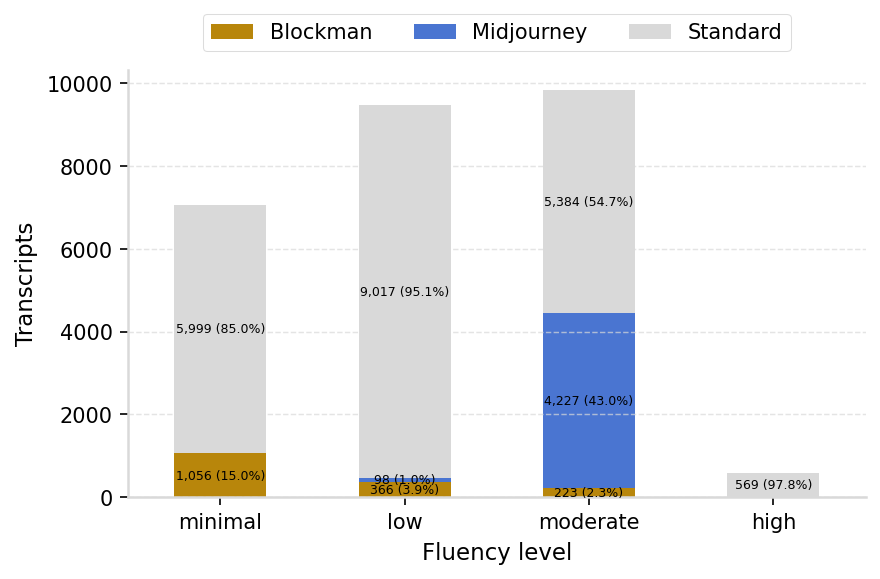

In [41]:
plot_fluency_dist(full_df)

## Fluency and complexity

In [42]:
def plot_fluency_and_complexity(df, output_filename="fluency-complexity.pdf"):
    fig, ax = plt.subplots(figsize=(6, 4))

    sns.barplot(
        data=df,
        x='fluency_assessment',
        y='complexity_score',
        hue="is_success",
        order=fluency_order,
        errorbar=('ci', 95), # bootstrapped
        n_boot=1000,
        capsize=0.0,
        palette=['#D7263D', '#1E88E5'],
        ax=ax
    )

    for container in ax.containers:
        ax.bar_label(container, fmt="{:.02f}", label_type='edge', fontsize=8, padding=5)

    totals = df.groupby("fluency_assessment")['complexity_score'].mean()
    totals = totals[fluency_order]

    # To get the right height: 
    
    fails = df.groupby("fluency_assessment").apply(
        lambda x: x[x.is_success==False]['complexity_score'].mean())
    fails = fails[fluency_order]    
    
    for x, (yval, total) in enumerate(zip(fails, totals)):
        ax.text(x, yval+0.4, f'Overall: {total:.02f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

    ax.set_ylim(1, 5)
    ax.set_xlabel('Fluency level')
    ax.set_ylabel('Mean complexity score')
    plt.legend(title='Task success')
    plt.tight_layout()
    output_filename = os.path.join(FIGURE_OUTPUT_DIRNAME, output_filename)
    plt.savefig(output_filename)
    plt.show()
    plt.close()

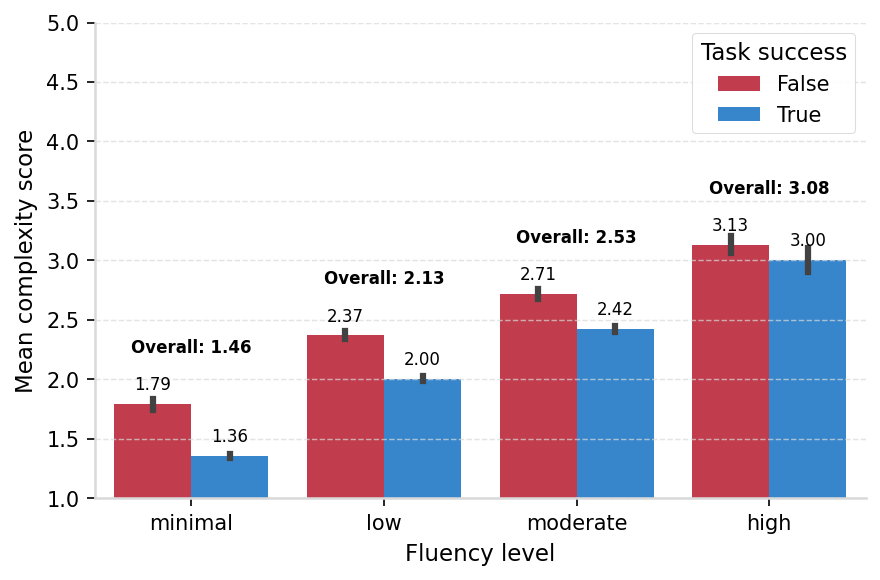

In [43]:
plot_fluency_and_complexity(standard_df)

## Regression models

In [44]:
lme4 = importr('lme4')
base = importr('base')
stats = importr('stats')
modelsummary = importr('modelsummary')

### Data prep

In [45]:
model_df = standard_df.copy()

In [46]:
model_df["fluency_scalar"] = model_df.fluency_assessment.apply(lambda x: fluency_order.index(x) + 1)

In [47]:
pv = model_df.primary_vertical.value_counts()
doms = pv[pv > 100].index.tolist()

In [48]:
model_df["domains"] = model_df.primary_vertical.apply(lambda x: x if x in doms else "other")

In [49]:
model_domain_dist = model_df.domains.value_counts()

In [50]:
# Percentage of cases put into the "other" bucket:

(model_domain_dist / model_domain_dist.sum())['other'].round(2)

np.float64(0.02)

In [51]:
model_df['is_success'] = (model_df.failure_visibility == "none")

In [52]:
model_df = model_df[
    ['is_success', 'n_turns', 'fluency_scalar', 
     'failure_visibility', 'domains', 'complexity_score', 
     'fluency_behavior_count']
]

In [53]:
vis_model_df = model_df[model_df.is_success == False]

In [54]:
vis_model_df['is_visible'] = model_df.failure_visibility == 'visible'

In [55]:
model_df.is_success.value_counts()

is_success
True     14052
False     6917
Name: count, dtype: int64

### Success model

In [56]:
with localconverter(ro.default_converter + pandas2ri.converter):
    r_model_df = ro.conversion.py2rpy(model_df)

r.assign('r_model_df', r_model_df)
r_model = r('''
    glmer(
        is_success ~ 1 + fluency_scalar + n_turns + complexity_score + fluency_behavior_count + (1 | domains),
        data=r_model_df,
        family=binomial,
        control=glmerControl(optimizer = "bobyqa")
    )''')

print(r('summary')(r_model))

r.assign('r_model', r_model)

r('''
modelsummary(list("Model 1" = r_model),
             output = "fig/glmm_table-success.tex",
             estimate = "{estimate} & {std.error} & {stars}",
             statistic = NULL,
             stars = TRUE,
             gof_omit = "IC|Log",
              coef_rename = c("fluency_scalar" = "ann{fluency}",                             
                             "n_turns" = "ann{n_turns}",
                             "complexity_score" = "ann{complexity_score}",
                             "fluency_behavior_count" = "ann{fluency_behavior_count}"))
''')


Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: is_success ~ 1 + fluency_scalar + n_turns + complexity_score +  
    fluency_behavior_count + (1 | domains)
   Data: r_model_df
Control: glmerControl(optimizer = "bobyqa")

      AIC       BIC    logLik -2*log(L)  df.resid 
  23377.5   23425.2  -11682.7   23365.5     20963 

Scaled residuals: 
   Min     1Q Median     3Q    Max 
  -5.0   -0.9    0.5    0.7 3951.5 

Random effects:
 Groups  Name        Variance Std.Dev.
 domains (Intercept) 0.2255   0.4749  
Number of obs: 20969, groups:  domains, 26

Fixed effects:
                        Estimate Std. Error z value Pr(>|z|)    
(Intercept)             2.087012   0.117535  17.757  < 2e-16 ***
fluency_scalar          0.111358   0.040746   2.733  0.00628 ** 
n_turns                -0.235792   0.008631 -27.320  < 2e-16 ***
complexity_score       -0.516904   0.021305 -24.262  < 2e-16 ***
fluency_behavior_count

R callback write-console: In addition:   
R callback write-console: Warning message:
  
R callback write-console: To compile a LaTeX document with this table, the following commands must be placed in the document preamble:

\usepackage{tabularray}
\usepackage{float}
\usepackage{graphicx}
\usepackage{codehigh}
\usepackage[normalem]{ulem}
\UseTblrLibrary{booktabs}
\UseTblrLibrary{siunitx}
\newcommand{\tinytableTabularrayUnderline}[1]{\underline{#1}}
\newcommand{\tinytableTabularrayStrikeout}[1]{\sout{#1}}
\NewTableCommand{\tinytableDefineColor}[3]{\definecolor{#1}{#2}{#3}}

To disable `siunitx` and prevent `modelsummary` from wrapping numeric entries in `\num{}`, call:

options("modelsummary_format_numeric_latex" = "plain")
 This warning appears once per session. 
  


### Visibility model

In [57]:
with localconverter(ro.default_converter + pandas2ri.converter):
    r_vis_model_df = ro.conversion.py2rpy(vis_model_df)

r.assign('r_vis_model_df', r_vis_model_df)
r_vis_model = r('''
    glmer(
        is_visible ~ 1 + fluency_scalar + n_turns + complexity_score + fluency_behavior_count + (1 | domains),
        data=r_vis_model_df,
        family=binomial,
        control=glmerControl(optimizer = "bobyqa")
    )''')

print(r('summary')(r_model))

r.assign('r_vis_model', r_vis_model)

r('''
modelsummary(list("Model 2" = r_vis_model),
             output = "fig/glmm_table-vis.tex",
             estimate = "{estimate} & {std.error} & {stars}",
             statistic = NULL,
             stars = TRUE,
             gof_omit = "IC|Log",
             coef_rename = c("fluency_scalar" = "ann{fluency}",                             
                             "n_turns" = "ann{n_turns}",
                             "complexity_score" = "ann{complexity_score}",
                             "fluency_behavior_count" = "ann{fluency_behavior_count}"))
''')

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: is_success ~ 1 + fluency_scalar + n_turns + complexity_score +  
    fluency_behavior_count + (1 | domains)
   Data: r_model_df
Control: glmerControl(optimizer = "bobyqa")

      AIC       BIC    logLik -2*log(L)  df.resid 
  23377.5   23425.2  -11682.7   23365.5     20963 

Scaled residuals: 
   Min     1Q Median     3Q    Max 
  -5.0   -0.9    0.5    0.7 3951.5 

Random effects:
 Groups  Name        Variance Std.Dev.
 domains (Intercept) 0.2255   0.4749  
Number of obs: 20969, groups:  domains, 26

Fixed effects:
                        Estimate Std. Error z value Pr(>|z|)    
(Intercept)             2.087012   0.117535  17.757  < 2e-16 ***
fluency_scalar          0.111358   0.040746   2.733  0.00628 ** 
n_turns                -0.235792   0.008631 -27.320  < 2e-16 ***
complexity_score       -0.516904   0.021305 -24.262  < 2e-16 ***
fluency_behavior_count

## Fluency over time

In [58]:
def plot_fluency_over_time(df, output_filename="monthly-fluency.pdf"):
    xtab = pd.crosstab(df.month, df.fluency_assessment)
    xtab = xtab[fluency_order]
    xtab_per = xtab.apply(lambda row: row / row.sum(), axis=1)        

    no_blockman_df = df[df.blockman == False]
    no_mid_df = df[df.midjourney == False]

    bxtab = pd.crosstab(no_blockman_df.month, no_blockman_df.fluency_assessment)
    bxtab = bxtab[fluency_order]
    bxtab_per = bxtab.apply(lambda row: row / row.sum(), axis=1) 
    bxtab_per = bxtab_per["minimal"]
    bxtab_per.name = "minimal (no Blockman)"
    ax = bxtab_per.plot.line(color=['#000000'], linestyle='dashed')

    mxtab = pd.crosstab(no_mid_df.month, no_mid_df.fluency_assessment)
    mxtab_per = mxtab.apply(lambda row: row / row.sum(), axis=1) 
    mxtab_per = mxtab_per["moderate"]
    mxtab_per.name = "moderate (no Midjourney)"
    ax = mxtab_per.plot.line(color=['#D95F02'], linestyle='dashed', ax=ax)

    ax = xtab_per.plot.line(ax=ax, color=['#000000', '#5CAD70', '#D95F02', '#7760FB'])
    
    ax.set_xlabel("")
    ax.set_xticks(range(len(xtab)), labels=xtab.index.tolist())
    ax.tick_params(axis='x', labelrotation=90)
    ax.set_ylabel("Percentage of transcripts per month", fontsize=12)    
    plt.legend(loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=3)
    plt.tight_layout()
    output_filename = os.path.join(FIGURE_OUTPUT_DIRNAME, output_filename)
    plt.savefig(output_filename)
    plt.show()
    plt.close() 

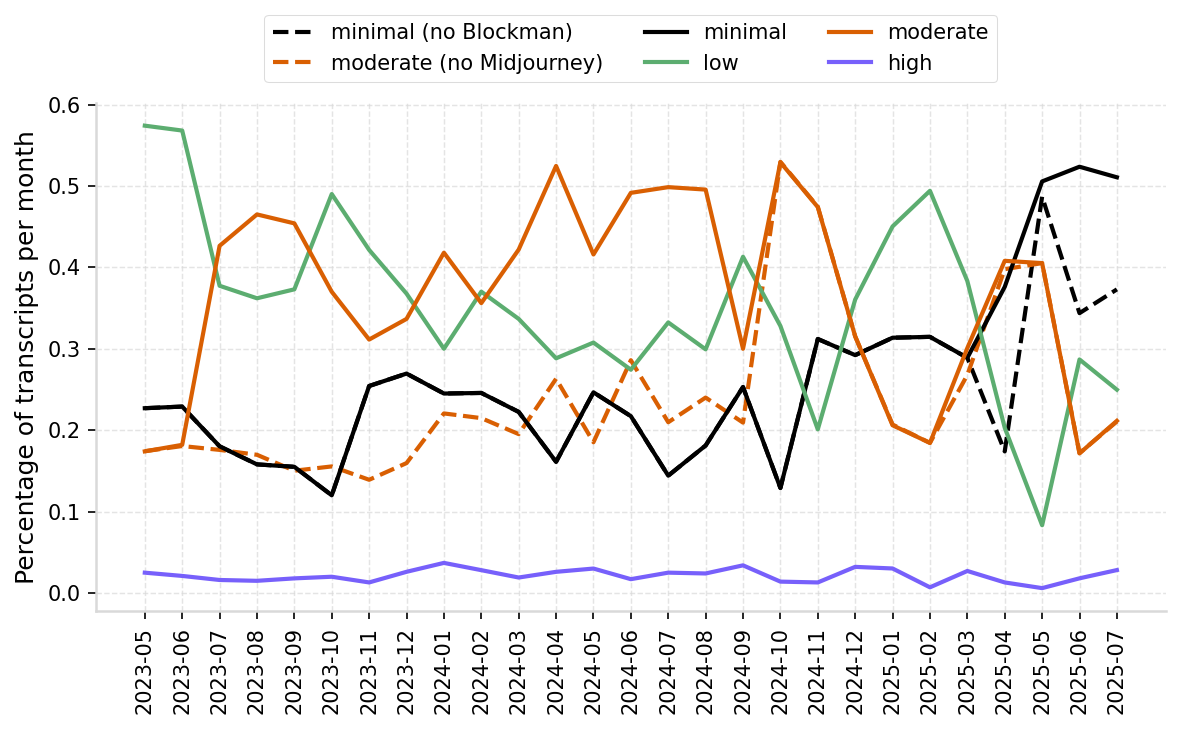

In [59]:
plot_fluency_over_time(full_df)

## Fluency and turns

In [60]:
def plot_fluency_and_turns(df, output_filename="fluency-turns.pdf"):

    xtab = df.groupby('fluency_assessment')['n_turns'].mean()
        
    ax = xtab.loc[fluency_order].plot.bar(figsize=(7, 3.5), color='gray')

    for container in ax.containers:
        ax.bar_label(container, fmt="{:,.02f}", label_type='edge', fontsize=8)
        
    ax.set_xlabel("Fluency level")
    ax.set_ylabel("Mean turn length")
    ax.grid(axis='x')
    ax.tick_params(axis='x', labelrotation=0)
    plt.tight_layout()
    output_filename = os.path.join(FIGURE_OUTPUT_DIRNAME, output_filename)
    plt.savefig(output_filename)
    plt.show()
    plt.close()

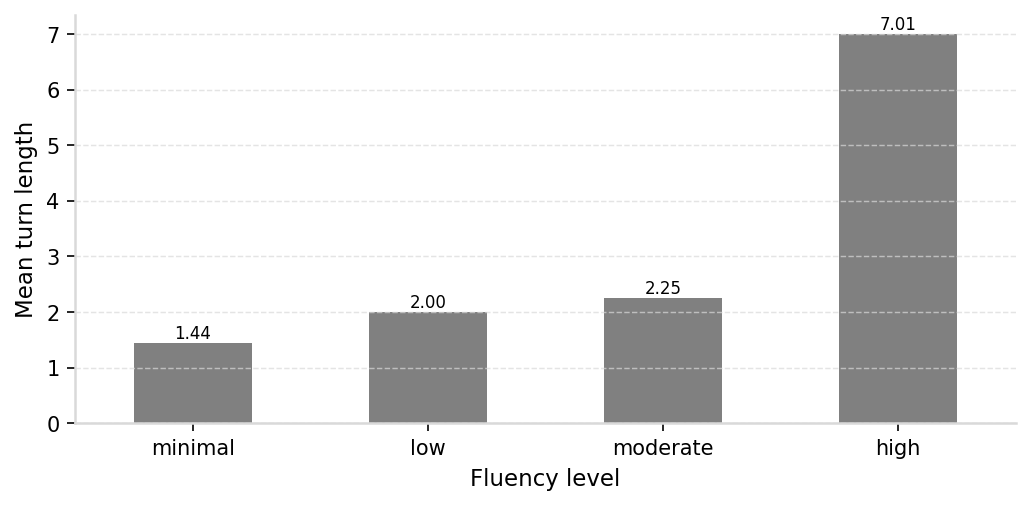

In [61]:
plot_fluency_and_turns(standard_df)

## Fluency and style

In [62]:
def plot_fluency_and_style(df, output_filename="fluency-style.pdf"):
    style = df.interaction_style_clean
    style.name = "Interaction style"
    fluency = df.fluency_assessment
    xtab = pd.crosstab(fluency, style)
    xtab = xtab.apply(lambda row: row / row.sum(), axis=1)
    ax = xtab.loc[fluency_order].plot.bar(figsize=(7, 3.5), color=['#7760FB', '#5CAD70', '#D9D9D9'] )

    for container in ax.containers:
        ax.bar_label(container, fmt="{:,.02f}", label_type='edge', fontsize=8)
        
    ax.set_xlabel("Fluency level")
    ax.set_ylabel("Percentage transcripts")
    ax.grid(axis='x')
    ax.tick_params(axis='x', labelrotation=0)
    plt.legend(loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=3)
    plt.tight_layout()
    output_filename = os.path.join(FIGURE_OUTPUT_DIRNAME, output_filename)
    plt.savefig(output_filename)
    plt.show()
    plt.close()

In [63]:
#plot_fluency_and_style(full_df)

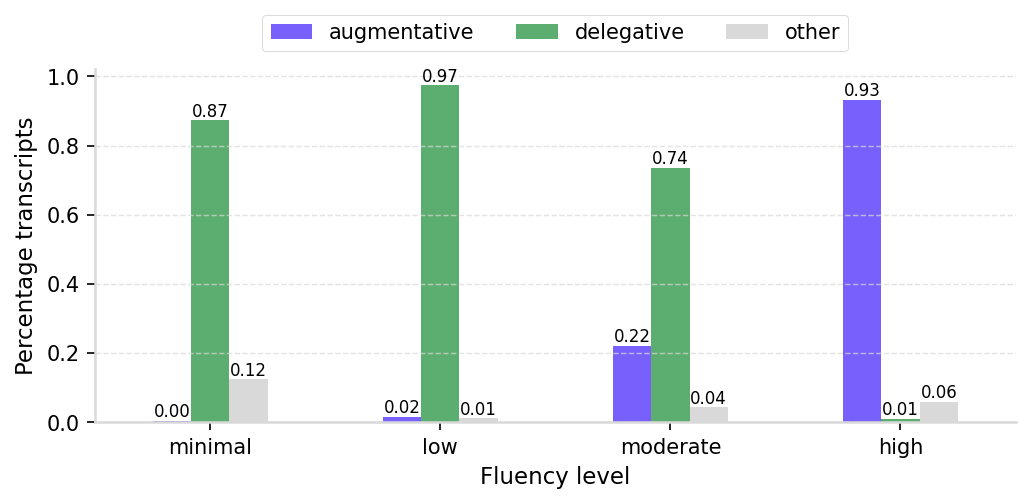

In [64]:
plot_fluency_and_style(standard_df, "fluency-style-standard.pdf")

## Fluency behavior counts

In [65]:
def fluency_behavior_counts(df, colname, output_filename_prefix="fluency"):
    fig, ax = plt.subplots(figsize=(5, 4))

    ax = sns.violinplot(data=df, x="fluency_assessment", y=df[colname],
                   color="steelblue", ax=ax, order=fluency_order)

    ax.set_xlabel("Fluency level")
    label = colname.replace("anti_", "anti-")
    label = label.replace("_", " ").capitalize()
    ax.set_ylabel(label, fontsize=12)    
    ax.tick_params(axis="x", rotation=0)

    plt.tight_layout()
    output_filename = f"{output_filename_prefix}-{colname}.pdf"
    output_filename = os.path.join(FIGURE_OUTPUT_DIRNAME, output_filename)
    plt.savefig(output_filename)
    plt.show()
    plt.close()   

In [66]:
#fluency_behavior_counts(full_df, 'fluency_behavior_count')

In [67]:
#fluency_behavior_counts(full_df, 'fluency_behavior_count')

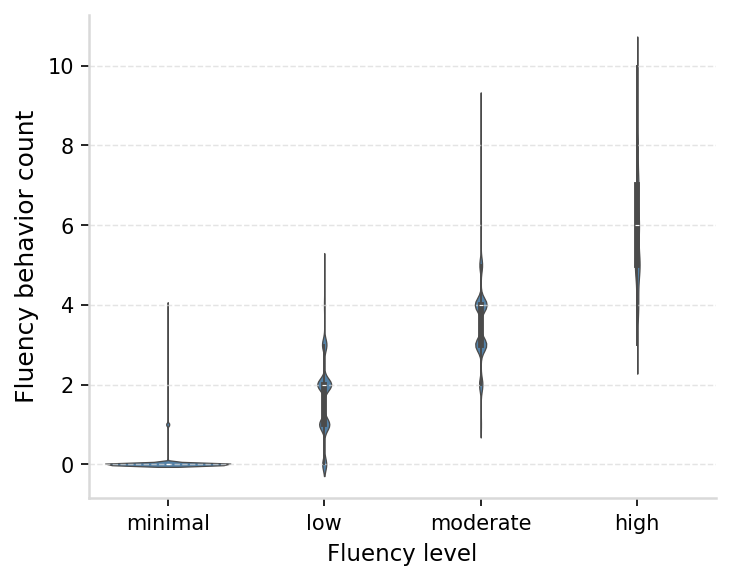

In [68]:
fluency_behavior_counts(standard_df, 'fluency_behavior_count', 'standard')

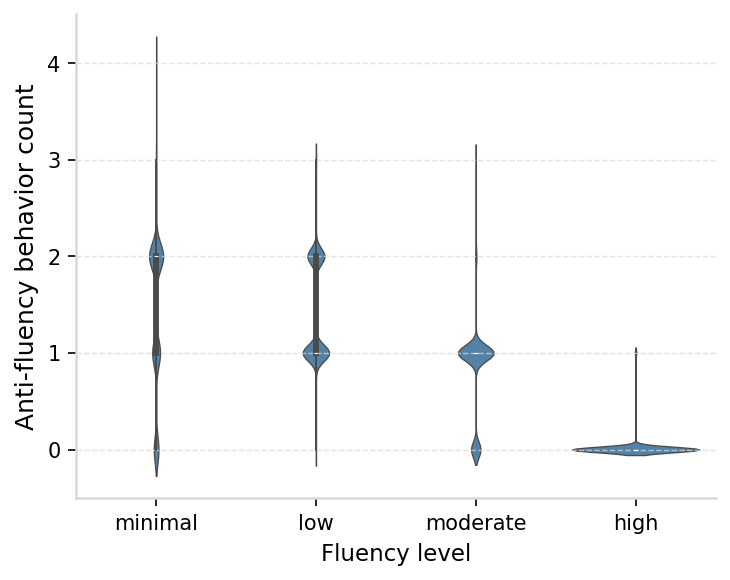

In [69]:
fluency_behavior_counts(standard_df, 'anti_fluency_behavior_count', 'standard')

## Fluency behavior distributions

In [70]:
def plot_behavior_dists(df, output_filename = f"behavior-dists.pdf"):

    all_fluent = sorted({x for vals in df.fluency_behaviors for x in vals if x != "passive_acceptance"})
    all_anti = sorted({x for vals in df.anti_fluency_behaviors for x in vals if x not in set(all_fluent) | {"passive_acceptan​ce"}})
    all_anti = sorted({"passive_acceptance" if x == "passive_accept" else x for x in all_anti})
    
    print(f"Number of distinct fluency tags: {len(all_fluent)}")
    print(f"Number of distinct anti-fluency tags: {len(all_anti)}")
        
    exploded_anti = df[["fluency_assessment", "anti_fluency_behaviors"]].explode(
        'anti_fluency_behaviors').reset_index(drop=True).rename(columns={"anti_fluency_behaviors": "behavior"})

    exploded = df[["fluency_assessment", "fluency_behaviors"]].explode(
        'fluency_behaviors').reset_index(drop=True).rename(columns={"fluency_behaviors": "behavior"})

    behave_df = pd.concat((exploded, exploded_anti)).reset_index(drop=True)

    xtab = pd.crosstab(behave_df.behavior, behave_df.fluency_assessment)
    xtab = xtab.apply(lambda x: x / x.sum(), axis=0).T

    good = xtab.loc[fluency_order[::-1], [c for c in xtab.columns if c in all_fluent]]

    bad = xtab.loc[fluency_order[::-1], [c for c in xtab.columns if c in all_anti]]

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    sns.heatmap(good.T, cmap="Blues", annot=True, linewidths=0.5, fmt=".5f", cbar_kws={"label": "P(behavior | fluency)"}, ax=axes[0])
    axes[0].set_ylabel("")
    axes[0].set_xlabel("Fluency assessment")
    axes[0].grid(False)
    sns.heatmap(bad.T, cmap="Reds", annot=True, linewidths=0.5, fmt=".5f", cbar_kws={"label": "P(behavior | fluency)"}, ax=axes[1])
    axes[1].set_ylabel("")
    axes[1].set_xlabel("Fluency assessment")
    axes[1].grid(False)
    plt.tight_layout()    
    output_filename = os.path.join(FIGURE_OUTPUT_DIRNAME, output_filename)
    plt.savefig(output_filename)
    plt.show()
    plt.close()   

In [71]:
#plot_behavior_dists(full_df)

Number of distinct fluency tags: 17
Number of distinct anti-fluency tags: 7


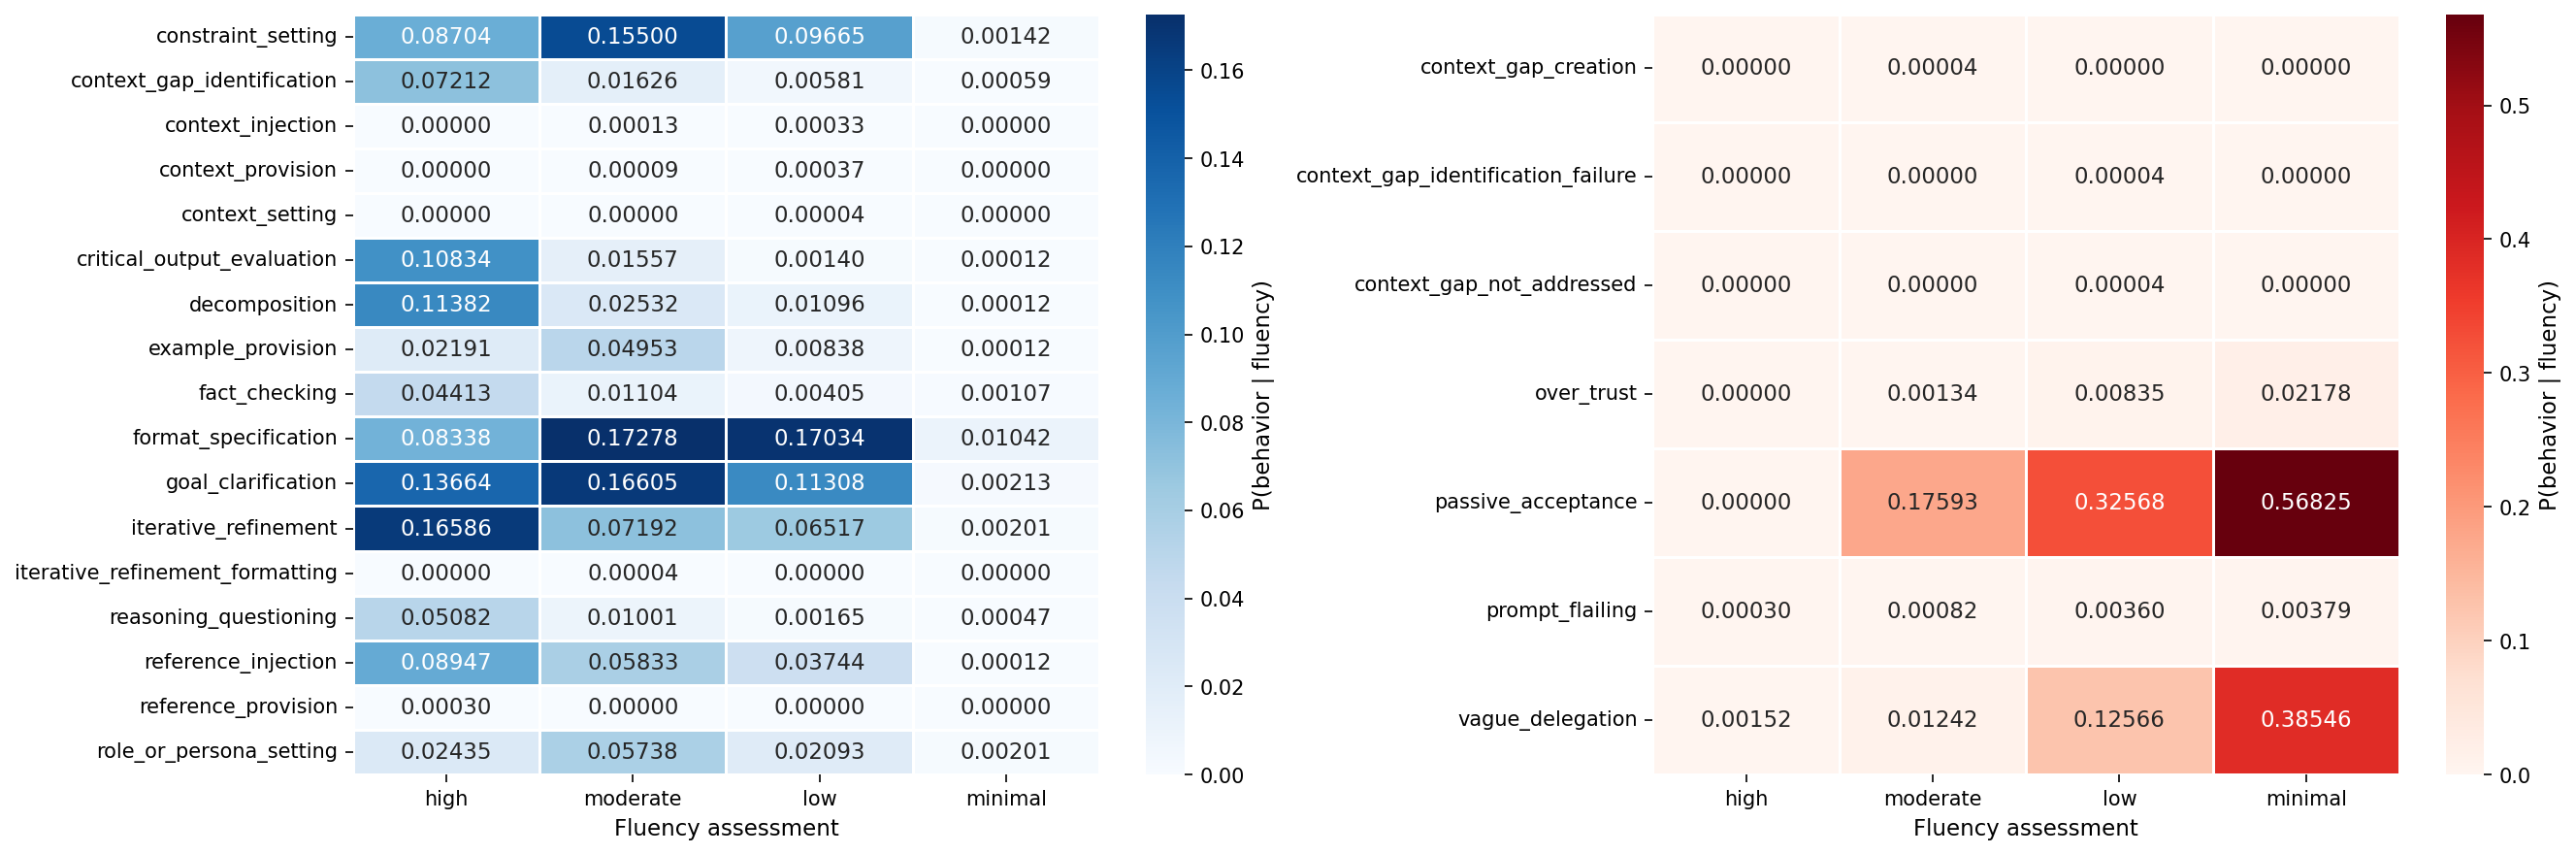

In [72]:
plot_behavior_dists(standard_df, "behavior-dists-standard.pdf")

## Fluency and failure

In [73]:
def fluency_and_failure(df, output_filename="fluency-failure.pdf", title=None):
    dist = pd.crosstab(df.fluency_assessment, df.failure_visibility)
    dist = dist.apply(lambda x: x / x.sum(), axis=1)
    dist = dist.drop("none", axis=1)
    dist = dist.loc[fluency_order]
    ax = dist.plot.bar(stacked=True, color=['#7760FB', '#D95F02', "#AAAAAA"], figsize=(9, 5))

    totals = dist.sum(axis=1)    

    for i, container in enumerate(ax.containers):
        col = dist.columns[i]        
        labels = [
            f'{v / total * 100:.1f}% of failures' if v > 0 else ''
            for v, total in zip(dist[col], totals)
        ]
        ax.bar_label(container, labels=labels, label_type='center', fontsize=7, color="white", fontweight='bold') 

    for x, total in enumerate(totals):
        ax.text(x, total, f'Total: {total:.02f}',ha='center', va='bottom', fontsize=8, fontweight='bold')
    
    ax.set_xlabel("Fluency level")    
    ax.set_ylabel("Percentage transcripts with a failure signal", fontsize=12)    
    ax.tick_params(axis="x", rotation=0)
    ax.set_ylim([0, 1])
    ax.grid(axis='x')
    if title is not None:
        ax.set_title(title)
    plt.tight_layout()
    plt.legend(title='Failure visibility')

    output_filename = os.path.join(FIGURE_OUTPUT_DIRNAME, output_filename)
    plt.savefig(output_filename)
    plt.show()
    plt.close() 

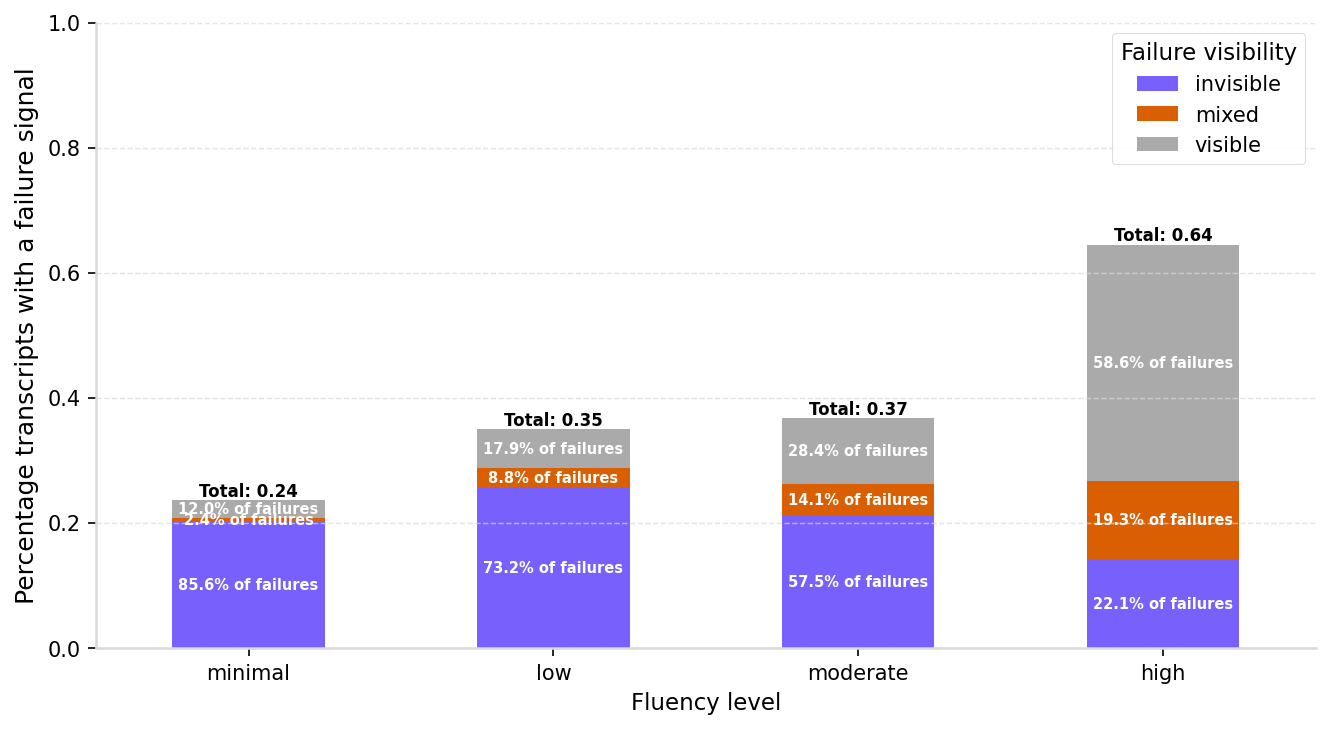

In [74]:
fluency_and_failure(standard_df, output_filename="fluency-failure-standard.pdf")

## Fluency and archetypes

In [75]:
def observed_over_expected(df):
    col_totals = df.sum(axis=0)
    total = col_totals.sum()
    row_totals = df.sum(axis=1)
    expected = np.outer(row_totals, col_totals) / total
    oe = df / expected
    return oe


def pmi(df, positive=True):
    df = observed_over_expected(df)
    # Silence distracting warnings about log(0):
    with np.errstate(divide='ignore'):
        df = np.log(df)
    df[np.isinf(df)] = 0.0  # log(0) = 0
    if positive:
        df[df < 0] = 0.0
    return df

In [76]:
fail_df = standard_df[standard_df.failure_visibility != "none"]

In [77]:
fail_df.shape

(6917, 47)

In [78]:
# Define a canonical ordering in which to display the archetypes,
# using prevalence in the main dataset as the primary factor, but
# with visible failures at the end:

all_archs = pd.Series([x for vals in fail_df.archetype_tags for x in vals])
all_archs_dist = all_archs.value_counts() 

canonical_archetype_ordering = all_archs_dist.index.tolist()
canonical_archetype_ordering.remove(visible_archetype_name)
canonical_archetype_ordering += [visible_archetype_name]
canonical_archetype_ordering = canonical_archetype_ordering[::-1]

In [79]:
def fluency_archetype_xtab(df):
    data = []
    for _, row in df.iterrows():
        for a in row.archetype_tags:
            data.append({
                'fluency_assessment': row['fluency_assessment'], 
                'archetype': a
            })  
    data = pd.DataFrame(data)
    xtab = pd.crosstab(data.fluency_assessment, data.archetype)
    return xtab

In [80]:
def fluency_archetype_plot(df, typ="ppmi", ann=None):
    X = fluency_archetype_xtab(df)
    heatmap_data = X.loc[
        fluency_order[::-1], 
        [c for c in canonical_archetype_ordering[::-1] if c in X.columns]
    ]    
    if typ == "ppmi":
        ylabel = "PPMI"
        heatmap_data = pmi(heatmap_data, positive=True)
        fmt=".2f"
    elif typ == "prob":
        ylabel = "P(archetype | fluency)"
        heatmap_data = (heatmap_data.T / heatmap_data.sum(axis=1)).T
        fmt=".2f"
    elif typ == "count":
        ylabel = "Co-occurrences"
        fmt="d"
    else:
        raise ValueError(f"typ value {typ} not recognised")        
    fig, ax = plt.subplots(figsize=(14, 6))
    sns.heatmap(heatmap_data, cmap="Purples", annot=True,
                fmt=fmt,
                linewidths=0.5, ax=ax,
                cbar_kws={"label": ylabel})
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(False)
    plt.tight_layout()
    if ann is not None:
        output_filename = f"fluency-archetypes_{typ}_{ann}.pdf"
    else:
        output_filename = f"fluency-archetypes_{typ}.pdf"
    output_filename = os.path.join(FIGURE_OUTPUT_DIRNAME, output_filename)
    plt.savefig(output_filename)
    plt.show()
    plt.close()

In [81]:
#fluency_archetype_plot(fail_df, typ="ppmi")

In [82]:
#fluency_archetype_plot(fail_df, typ="prob")

In [83]:
#fluency_archetype_plot(fail_df, typ="count")

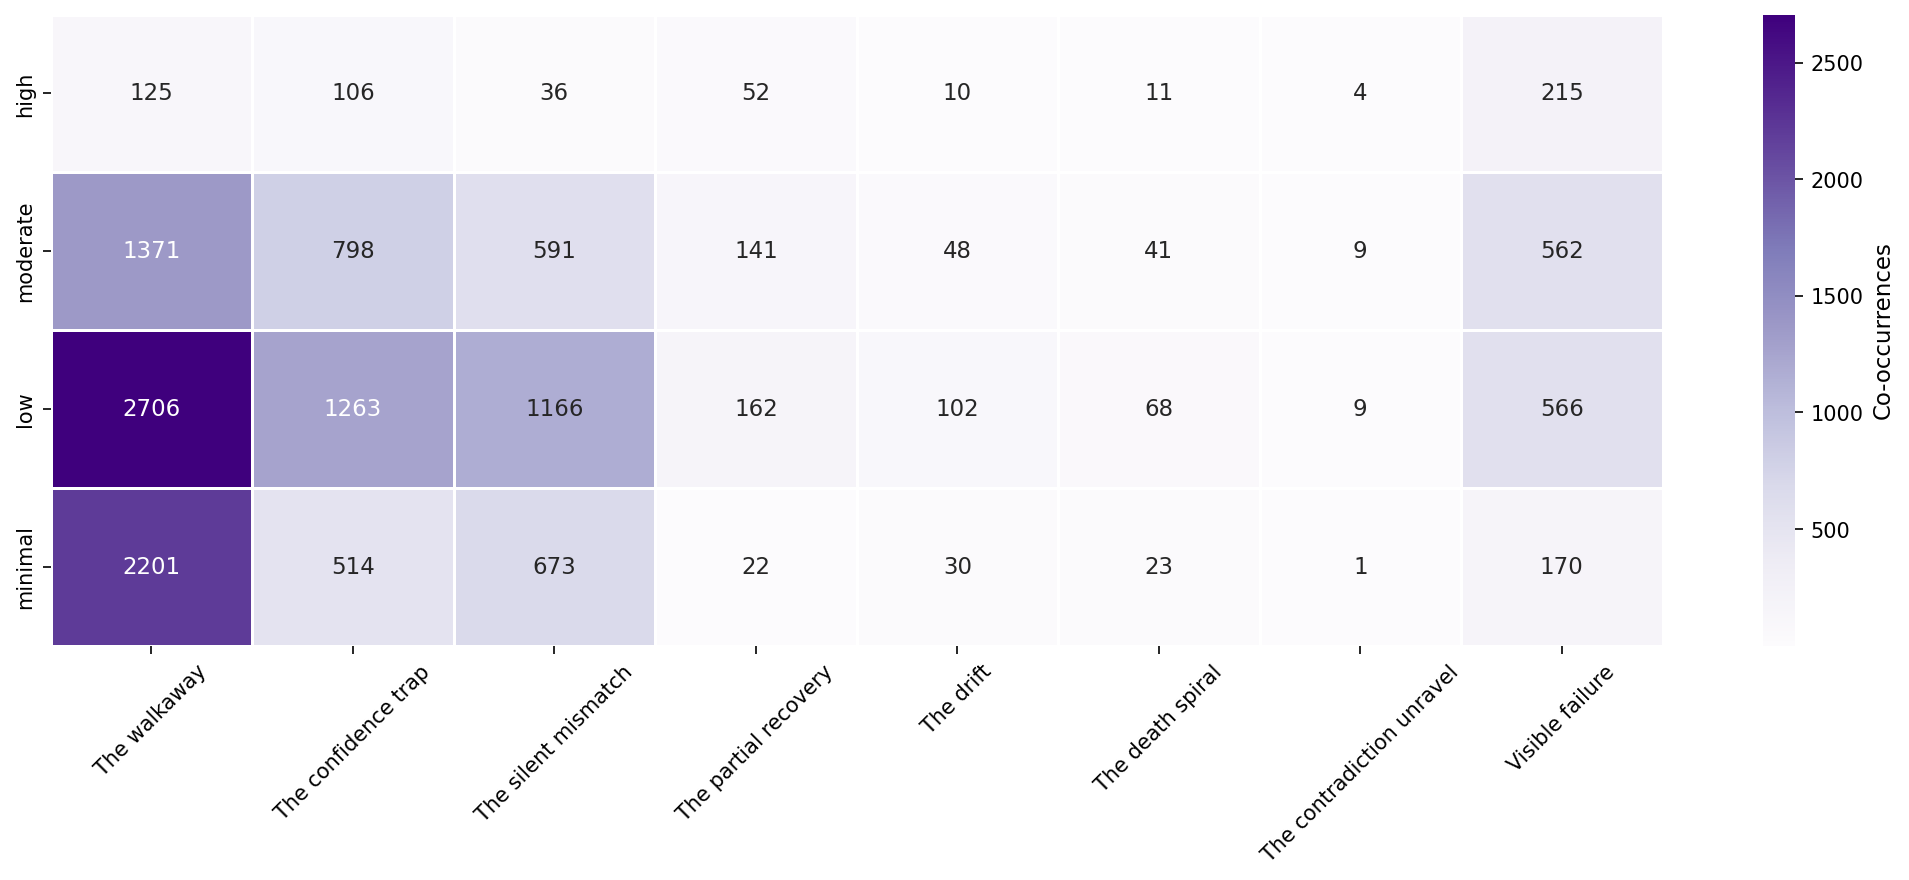

In [84]:
fluency_archetype_plot(standard_df, typ="count", ann="standard")

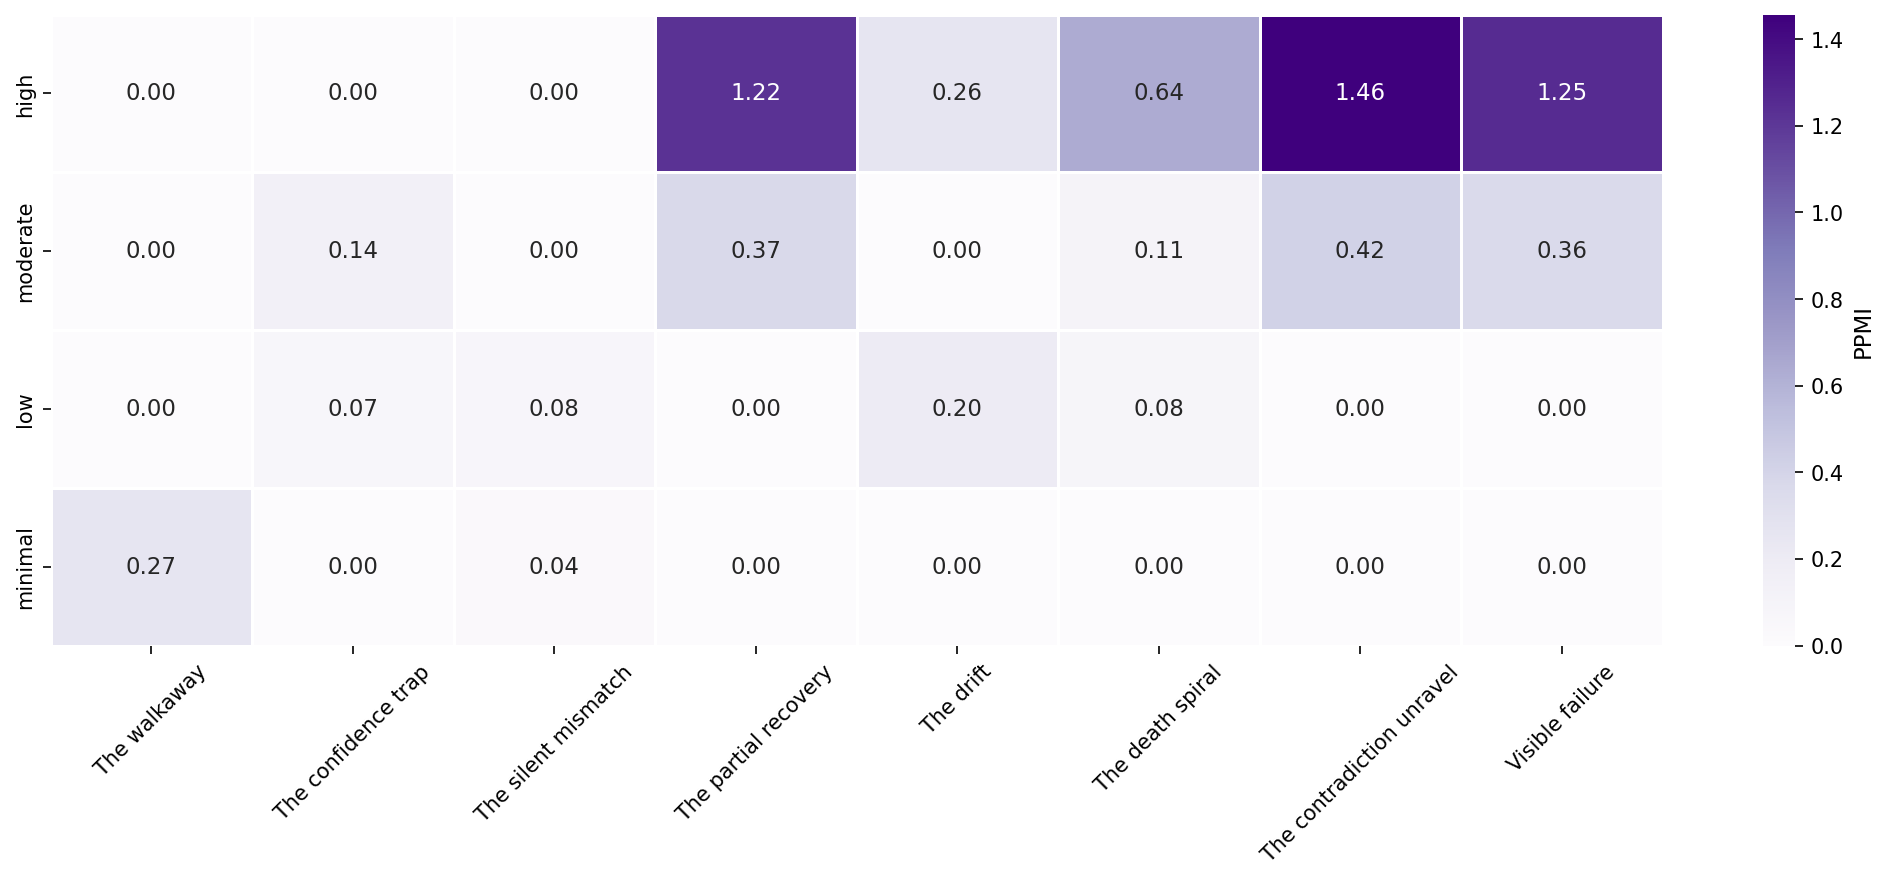

In [85]:
fluency_archetype_plot(standard_df, typ="ppmi", ann="standard")

## Archetype distribution

In [86]:
def archetype_dist_plot(df, output_filename="archetypes.pdf"):
    archs = pd.Series([x for vals in df.archetype_tags for x in vals])
    dist = archs.value_counts() 

    colors = ['#7760FB'] * (len(canonical_archetype_ordering) - 1)
    colors = ["#AAAAAA"] + colors
    
    for c in canonical_archetype_ordering:
        if c not in dist:
            dist[c] = 0.0
    ax = dist[canonical_archetype_ordering].plot.barh(figsize=(8, 4), color=colors)
    total = df.shape[0] # Total transcripts
    for patch in ax.patches:
        count = int(patch.get_width())
        pct = count / total * 100
        y_center = patch.get_y() + patch.get_height() / 2  
        x_pos = patch.get_width()
        if pct > 0.051:
            ax.text(x_pos + 1, y_center, f"{count:,}; {pct:.1f}%", va="center", fontsize=8)
        else:
            ax.text(x_pos + 1, y_center, f"{count:,}; < 0.05%", va="center", fontsize=8)
    ax.set_ylabel("")
    ax.set_xlabel("Archetype frequency")
    ax.grid(axis='y')
    plt.tight_layout()
    output_filename = os.path.join(FIGURE_OUTPUT_DIRNAME, output_filename)
    plt.savefig(output_filename)
    plt.show()
    plt.close()

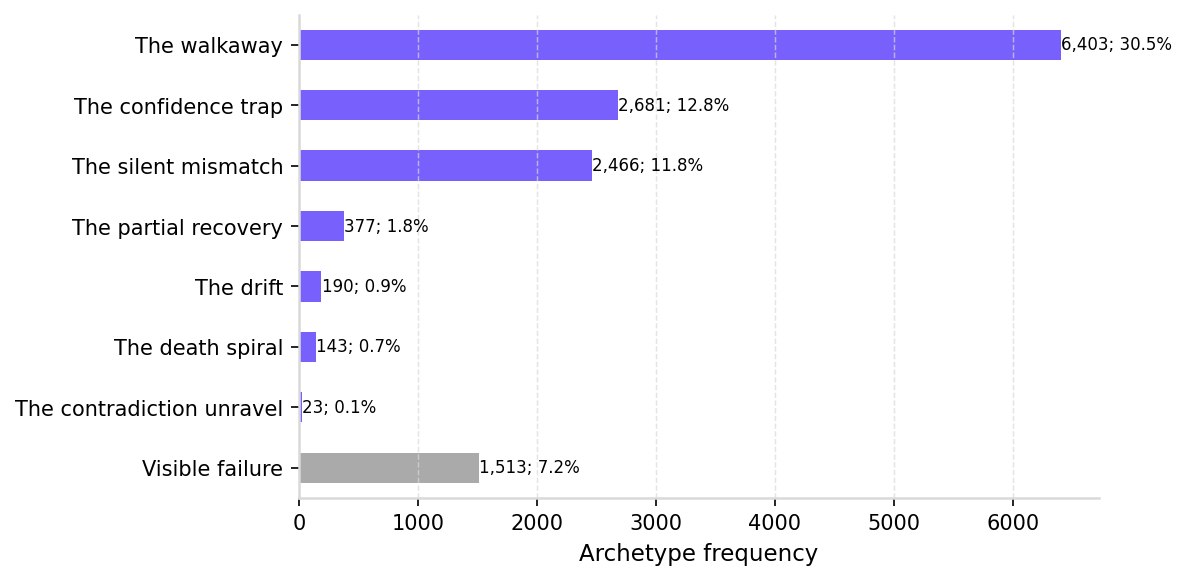

In [87]:
archetype_dist_plot(standard_df)